In [1]:
import os

libomp_path = "/opt/homebrew/opt/libomp/lib"
libomp_include = "/opt/homebrew/opt/libomp/include"

os.environ["DYLD_LIBRARY_PATH"] = libomp_path + os.pathsep + os.environ.get("DYLD_LIBRARY_PATH", "")
os.environ["LIBRARY_PATH"] = libomp_path + os.pathsep + os.environ.get("LIBRARY_PATH", "")
os.environ["CPATH"] = libomp_include + os.pathsep + os.environ.get("CPATH", "")

print("libomp path configured for XGBoost")


libomp path configured for XGBoost


In [2]:
import json
import pandas as pd
import numpy as np

with open("data2.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(df.head())

print(df.shape)
print(df.dtypes)
print(df["click"].value_counts())
print(df["click"].value_counts(normalize=True))


   hours_spent_reading_a  hours_spent_reading_b  hours_spent_reading_c  \
0                   3.91                   0.35                   1.80   
1                   0.79                   4.50                   3.36   
2                   0.37                   1.47                   3.13   
3                   4.35                   4.27                   2.63   
4                   4.89                   0.24                   4.87   

  current_post_category  click  
0                     A      1  
1                     C      0  
2                     A      0  
3                     B      0  
4                     C      0  
(500, 5)
hours_spent_reading_a    float64
hours_spent_reading_b    float64
hours_spent_reading_c    float64
current_post_category        str
click                      int64
dtype: object
click
0    410
1     90
Name: count, dtype: int64
click
0    0.82
1    0.18
Name: proportion, dtype: float64


In [3]:
df.describe()

,hours_spent_reading_a,hours_spent_reading_b,hours_spent_reading_c,click
count,500.000000,500.000000,500.00000,500.000000
mean,2.950020,3.190340,3.05086,0.180000
std,1.669743,1.643178,1.72131,0.384572
min,0.210000,0.210000,0.22000,0.000000
25%,1.477500,1.857500,1.57000,0.000000
50%,2.755000,3.325000,2.97500,0.000000
75%,4.352500,4.610000,4.61000,0.000000
max,6.000000,5.990000,5.98000,1.000000


In [4]:
print (df.isna().sum())
df["click"].value_counts(normalize=True)

hours_spent_reading_a    0
hours_spent_reading_b    0
hours_spent_reading_c    0
current_post_category    0
click                    0
dtype: int64


click
0    0.82
1    0.18
Name: proportion, dtype: float64

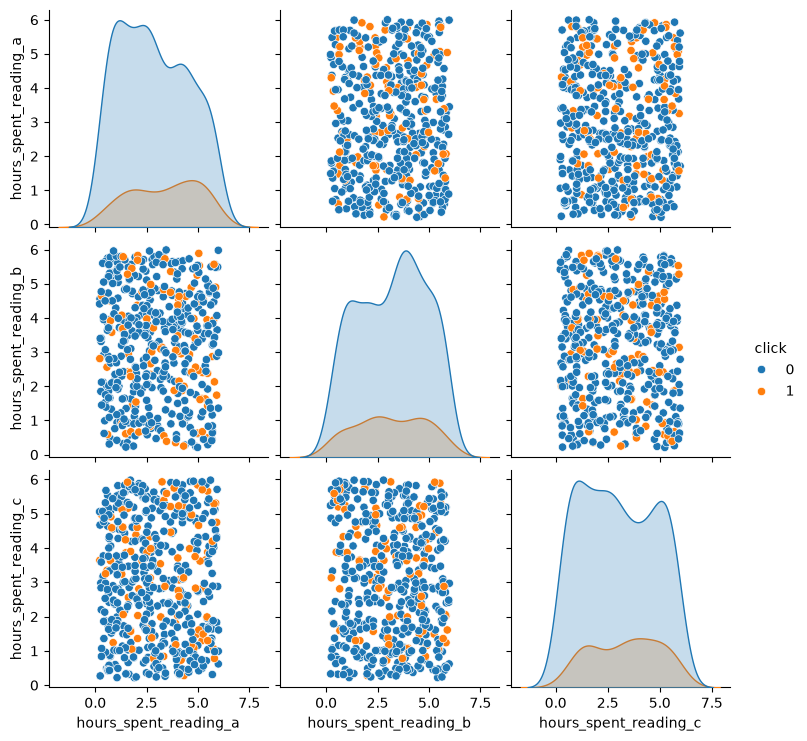

In [5]:
# import matplotlib.pyplot as plt
# plt.plot(df.click)
import seaborn as sns


sns.pairplot(df, hue="click")

In [6]:
import os

libomp_path = "/opt/homebrew/opt/libomp/lib"
os.environ["DYLD_LIBRARY_PATH"] = libomp_path + os.pathsep + os.environ.get("DYLD_LIBRARY_PATH", "")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from xgboost import XGBClassifier

feature_cols = [c for c in df.columns if c != 'click']
X = pd.get_dummies(df[feature_cols], columns=['current_post_category'], drop_first=False)
y = df['click']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    'Log Loss': [
        log_loss(y_test, lr_prob),
        log_loss(y_test, rf_prob),
        log_loss(y_test, xgb_prob)
    ]
})

print('\nModel comparison:')
print(results.round(3))
print('\nLogistic regression coefficients:')
print(pd.Series(lr.coef_[0], index=X.columns).sort_values(ascending=False))



Model comparison:
                 Model  Accuracy  ROC-AUC  Log Loss
0  Logistic Regression      0.82    0.676     0.451
1        Random Forest      0.82    0.601     0.475
2              XGBoost      0.78    0.580     0.594

Logistic regression coefficients:
current_post_category_B    0.294289
hours_spent_reading_a      0.171243
hours_spent_reading_c      0.078252
hours_spent_reading_b      0.011774
current_post_category_C   -0.015314
current_post_category_A   -0.279455
dtype: float64


In [9]:
import os

libomp_path = "/opt/homebrew/opt/libomp/lib"
os.environ["DYLD_LIBRARY_PATH"] = libomp_path + os.pathsep + os.environ.get("DYLD_LIBRARY_PATH", "")

from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

feature_cols = [c for c in df.columns if c != 'click']
X = pd.get_dummies(df[feature_cols], columns=['current_post_category'], drop_first=False)
y = df['click']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss'
)

lr_scores = cross_val_score(lr, X, y, cv=cv, scoring='f1_weighted')
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_weighted')
xgb_scores = cross_val_score(xgb, X, y, cv=cv, scoring='f1_weighted')

cv_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'CV Accuracy Scores': [lr_scores.tolist(), rf_scores.tolist(), xgb_scores.tolist()],
    'Mean CV Accuracy': [lr_scores.mean(), rf_scores.mean(), xgb_scores.mean()],
    'Std CV Accuracy': [lr_scores.std(), rf_scores.std(), xgb_scores.std()]
})

print(cv_results.round(3))


                 Model                                 CV Accuracy Scores  \
0  Logistic Regression  [0.738901098901099, 0.738901098901099, 0.73890...   
1        Random Forest  [0.7237988826815642, 0.7134463276836158, 0.763...   
2              XGBoost  [0.7266285714285714, 0.7134463276836158, 0.746...   

   Mean CV Accuracy  Std CV Accuracy  
0             0.739            0.000  
1             0.740            0.022  
2             0.727            0.017  


In [17]:
a = np.zeros([1, 2])
b = np.ones([1, 2])
# a, b
np.dot(a,b.T)
np.dot(a.T,b)

array([[0., 0.],
       [0., 0.]])